# Obesity Level Analysis — Data Cleaning & Exploratory Data Analysis

**Data Analytics Final Project**

This notebook covers the **data preparation** and **exploratory data analysis (EDA)** stages of the project. It takes the raw obesity dataset, assesses and fixes data quality issues, then explores distributions, relationships, and patterns that explain how lifestyle and demographic factors relate to obesity level.

**Workflow covered in this notebook:**
1. Dataset overview
2. Initial data inspection
3. Data quality assessment (missing values, duplicates)
4. Data cleaning
5. Exploratory data analysis (univariate, bivariate, correlation)
6. Key insights summary
7. Export of the cleaned dataset

The cleaned dataset produced at the end of this notebook feeds directly into the **Power BI dashboard**, and predictive modeling (Logistic Regression, Decision Tree, Random Forest, SVM) is carried out separately.

## 1. Dataset Overview

The dataset contains **2,111 records** collected from individuals in **Mexico, Peru, and Colombia**. It includes 16 lifestyle and health-related features, with obesity levels classified into seven categories ranging from underweight to various obesity types.

**Features:**

| Feature | Description |
|---|---|
| `Gender` | Male or Female |
| `Age` | Age in years |
| `Height` | Height in meters |
| `Weight` | Weight in kilograms |
| `family_history_with_overweight` | Whether the person has a family history of being overweight (yes/no) |
| `FAVC` | Frequent consumption of high-calorie foods (yes/no) |
| `FCVC` | Frequency of vegetable consumption (scale 1–3) |
| `NCP` | Number of main meals per day |
| `CAEC` | Frequency of eating between meals (Never, Sometimes, Frequently, Always) |
| `SMOKE` | Whether the person smokes (yes/no) |
| `CH2O` | Daily water intake (scale 1–3) |
| `SCC` | Whether the person monitors calorie intake (yes/no) |
| `FAF` | Physical activity frequency (scale 0–3) |
| `TUE` | Time spent using technology (scale 0–2) |
| `CALC` | Frequency of alcohol consumption (Never, Sometimes, Frequently, Always) |
| `MTRANS` | Main mode of transportation |

**Target variable:**
- `NObeyesdad`: Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, Obesity Type III

## 2. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, presentation-ready plot style used throughout the notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

# Class order used consistently across all charts so severity reads left-to-right
CLASS_ORDER = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I", "Overweight_Level_II",
    "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"
]

## 3. Load the Dataset

In [25]:
df = pd.read_csv("obesity_data .csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 2111 rows, 17 columns


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,35,1.71,84.72,yes,yes,2.88,3.0,Sometimes,no,3.00,no,2.00,0.832,no,Automobile,Overweight_Level_II
1,Male,19,1.75,100.00,yes,yes,2.00,3.0,Frequently,no,2.00,no,2.00,0.000,no,Public_Transportation,Obesity_Type_I
2,Male,19,1.85,65.00,yes,no,2.00,3.0,Sometimes,no,3.00,no,2.00,1.000,Sometimes,Bike,Normal_Weight
3,Male,31,1.78,120.64,yes,yes,NaN,3.0,Sometimes,no,2.04,no,0.84,0.490,Sometimes,Automobile,Obesity_Type_II
4,Male,25,1.80,120.90,yes,yes,NaN,3.0,Sometimes,no,2.51,no,1.66,0.128,Sometimes,Public_Transportation,Obesity_Type_II


## 4. Initial Data Inspection

Before cleaning anything, it's important to understand the structure of the data: column types, value ranges, and whether numeric columns were parsed correctly.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            1773 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

**Summary statistics — numerical features:**

In [27]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,1773.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701620,86.586035,2.408579,2.685651,2.008053,1.010313,0.657861
std,6.357078,0.093368,26.191163,0.535804,0.778079,0.612950,0.850613,0.608926
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.630000,65.470000,2.000000,2.660000,1.585000,0.125000,0.000000
50%,23.000000,1.700000,83.000000,2.330000,3.000000,2.000000,1.000000,0.625000
75%,26.000000,1.770000,107.430000,3.000000,3.000000,2.480000,1.670000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


**Summary statistics — categorical features:**

In [28]:
df.describe(include="object")

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,1900,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1265,1580,351


## 5. Data Quality Assessment

Two checks are run before any cleaning: **missing values** and **duplicate rows**. Both need to be identified first so the cleaning strategy can be chosen deliberately (e.g. mean vs. mode imputation) rather than dropped blindly.

In [29]:
def check_missing_values(data):
    """Return a summary of columns containing missing/blank values."""
    empty_cells = data.isna() | data.astype(str).apply(lambda x: x.str.strip() == "")
    empty_count = empty_cells.sum()
    empty_percentage = (empty_count / len(data)) * 100
    result = pd.DataFrame({
        "column": empty_count.index,
        "null_count": empty_count.values,
        "null_percentage": empty_percentage.values.round(2)
    })
    result = result[result["null_count"] > 0]
    if result.empty:
        return "No missing values found."
    return result.sort_values("null_count", ascending=False).reset_index(drop=True)

check_missing_values(df)

,column,null_count,null_percentage
0,FCVC,338,16.01
1,CALC,211,10.00


**Observation:** two columns have missing values — `FCVC` (~16% missing) and `CALC` (~10% missing). Neither is large enough to justify dropping the column, so both will be imputed.

Next, duplicate rows are checked — repeated records would otherwise bias distributions and let the same observation count multiple times in the analysis.

In [30]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 21


## 6. Data Cleaning

**Strategy:**
- `FCVC` is a numerical scale (1–3) with a roughly symmetric distribution, so missing values are imputed with the **mean**.
- `CALC` is categorical, so missing values are imputed with the **mode** (the most frequent category, `"Sometimes"`), which preserves the class distribution better than an arbitrary placeholder.
- Duplicate rows are dropped outright, since they add no new information and would double-count individuals in the analysis.

In [31]:
df["FCVC"] = df["FCVC"].fillna(df["FCVC"].mean())
df["CALC"] = df["CALC"].fillna(df["CALC"].mode()[0])

# Verify no missing values remain
check_missing_values(df)

'No missing values found.'

In [32]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate rows ({before} -> {after} rows).")

Removed 21 duplicate rows (2111 -> 2090 rows).


## 7. Post-Cleaning Summary

The dataset is now free of missing values and duplicate rows, and data types are appropriate for analysis. This is the version of the data used for the rest of the notebook.

In [33]:
print(f"Final dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values remaining: {df.isna().sum().sum()}")
print(f"Duplicate rows remaining: {df.duplicated().sum()}")
df.describe()

Final dataset shape: 2090 rows, 17 columns
Missing values remaining: 0
Duplicate rows remaining: 0


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2090.000000,2090.000000,2090.000000,2090.000000,2090.000000,2090.000000,2090.00000,2090.000000
mean,24.347847,1.702517,86.821589,2.410096,2.699718,2.004306,1.01233,0.663036
std,6.379948,0.093224,26.191489,0.491409,0.765944,0.609027,0.85317,0.607978
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,20.000000,1.630000,65.932500,2.000000,2.700000,1.582500,0.12250,0.000000
50%,23.000000,1.700000,83.015000,2.408579,3.000000,2.000000,1.00000,0.631000
75%,26.000000,1.770000,108.007500,3.000000,3.000000,2.467500,1.67750,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.00000,2.000000


## 8. Exploratory Data Analysis

With clean data in hand, the goal of this section is to understand:
- How is the **target variable** (obesity level) distributed?
- What do the **individual features** look like (shape, spread, outliers)?
- How do features **relate to obesity level** and to each other?

These findings directly inform which variables are likely to matter for the predictive modeling stage, and which visuals are worth carrying into the Power BI dashboard.

### 8.1 Target Variable: Obesity Level Distribution

Checking the balance of the target class is the first step in any classification problem — a heavily imbalanced target would need special handling (resampling, class weights) before modeling.

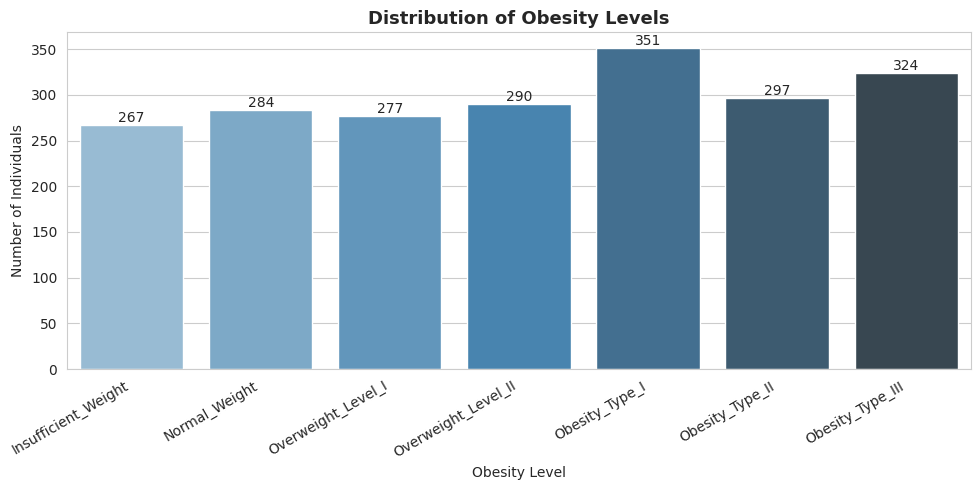

In [34]:
plt.figure(figsize=(10, 5))

obesity_counts = df["NObeyesdad"].value_counts().reindex(CLASS_ORDER)

ax = sns.barplot(
    x=obesity_counts.index,
    y=obesity_counts.values,
    hue=obesity_counts.index,
    palette="Blues_d",
    legend=False
)

plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

**Insight:** the seven classes are reasonably balanced (between ~270 and ~350 individuals each), with no severe minority class. This means the dataset can support multi-class classification without heavy resampling.

### 8.2 Numerical Feature Distributions

Histograms with a density curve (KDE) reveal the shape of each numerical variable — whether it's symmetric, skewed, or concentrated around specific values (a common pattern for survey-scale variables like `FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`).

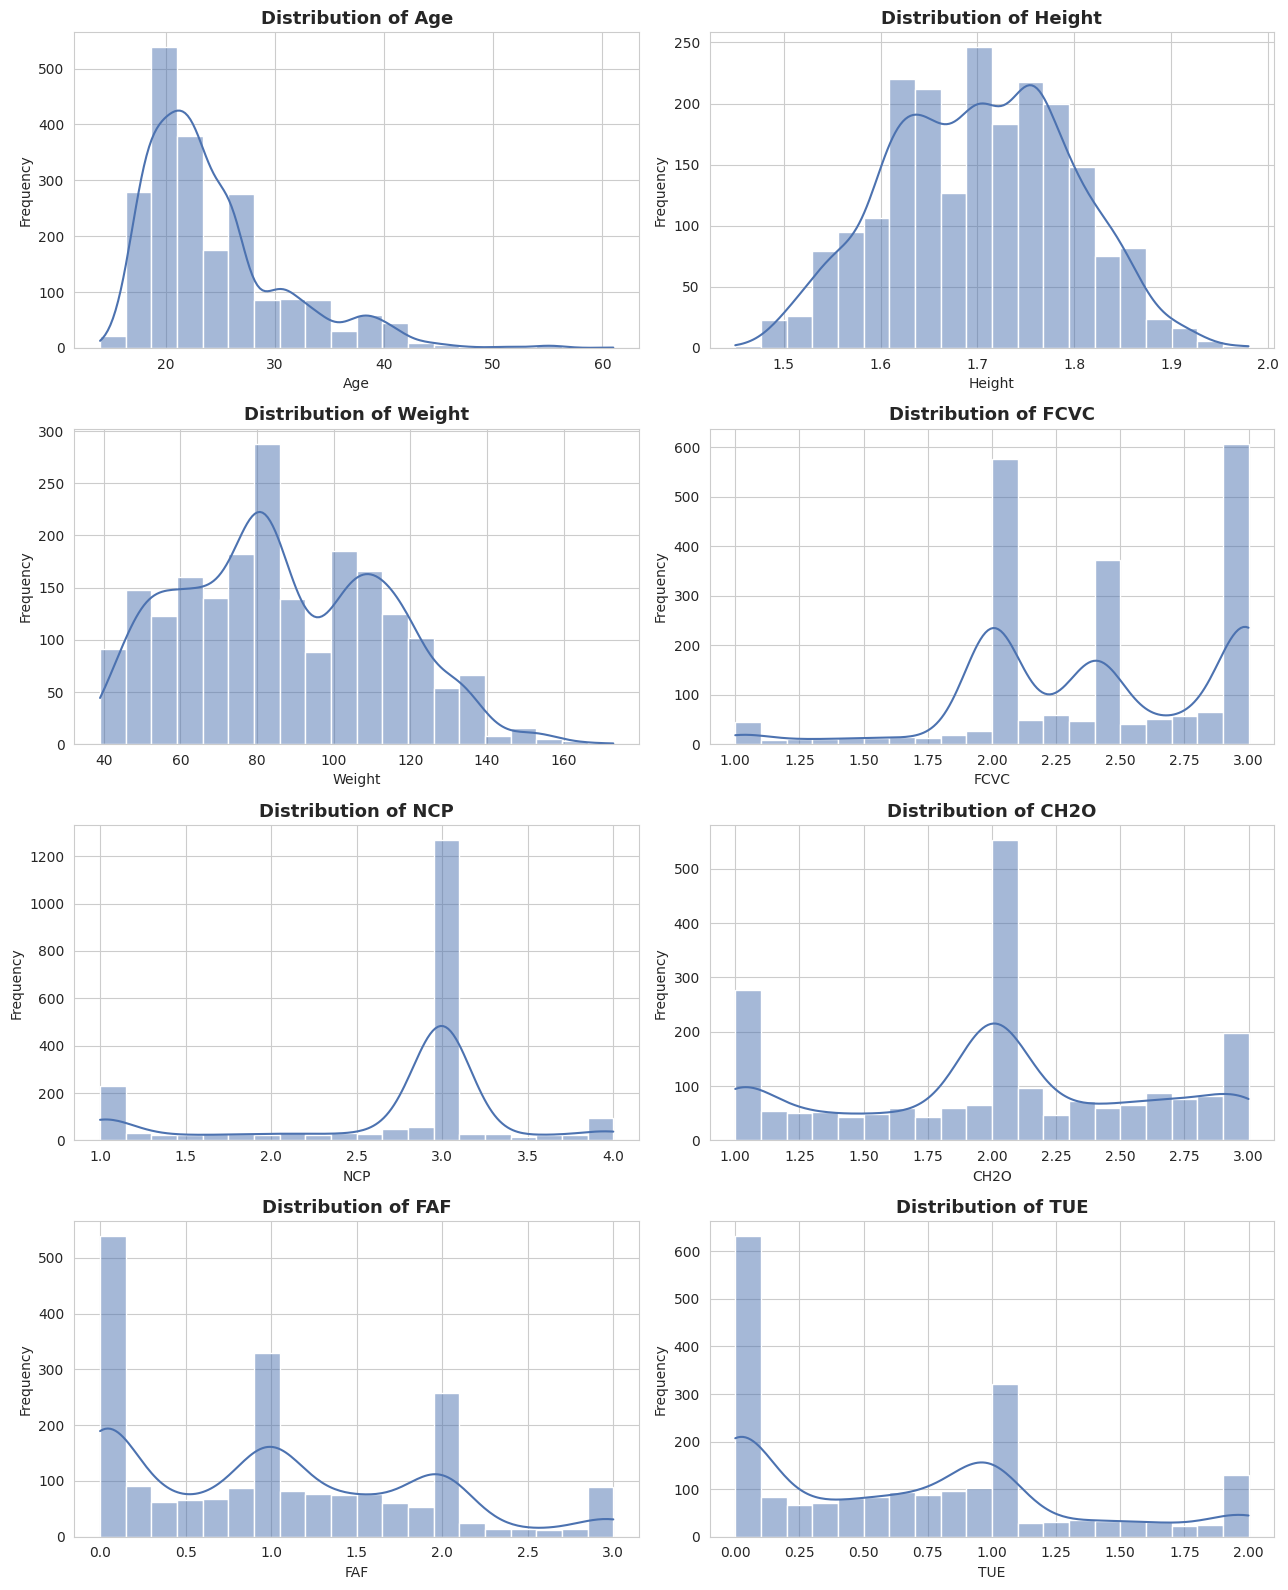

In [35]:
numerical_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    sns.histplot(data=df, x=col, kde=True, bins=20, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insight:**
- `Age` is **right-skewed** — most participants are young adults (20s), with a long tail toward older ages.
- `NCP` (meals per day) is **left-skewed and clustered near 3** — most people report a fairly standard three-meal routine.
- `FAF` (physical activity) and `TUE` (technology use) are both **right-skewed toward low values**, meaning a large share of the sample is relatively inactive / low screen-time on this particular scale.
- `Height` and `Weight` are close to symmetric, consistent with a general population sample rather than a clinical one.

### 8.3 Categorical Feature Distributions

Bar charts show how balanced (or imbalanced) each categorical feature is. Highly imbalanced binary features (e.g. almost everyone answering "no") carry less discriminative signal on their own.

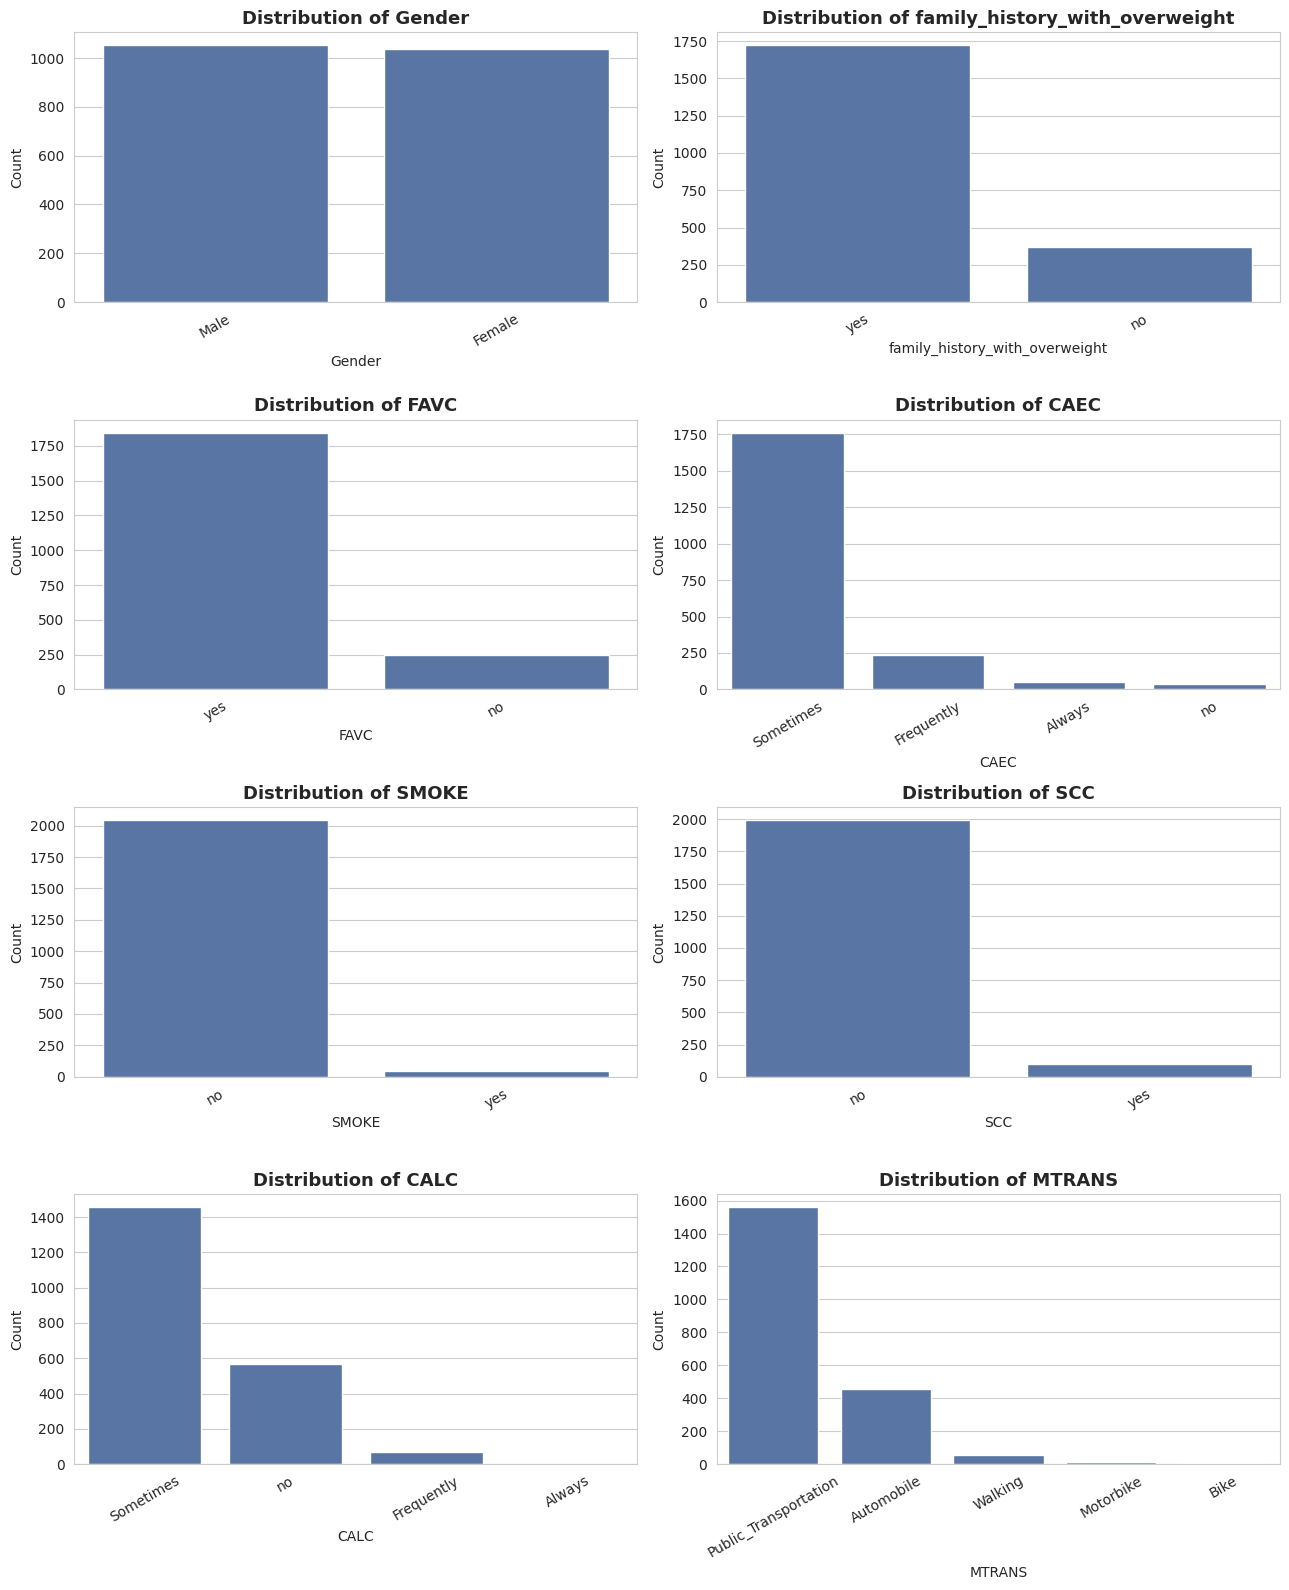

In [36]:
categorical_cols = [
    "Gender", "family_history_with_overweight", "FAVC",
    "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"
]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Insight:**
- `Gender` is almost perfectly balanced (about 50/50).
- `family_history_with_overweight` is skewed toward **"yes"** (~82%), which already hints at a relationship with the target explored below.
- `SMOKE` (~98% "no") and `SCC` (~95% "no") are **heavily imbalanced** — as standalone features they carry limited predictive power, but may still be useful in combination with other variables.
- `MTRANS` is dominated by **Public Transportation** (~75%), consistent with an urban sample.

### 8.4 Outlier Detection (Boxplots)

Boxplots highlight values that fall far outside the typical range for each numerical feature. This is a detection step only — outlier treatment is left to the modeling stage, where the choice of technique (capping, removal, or leaving as-is) depends on the model being used.

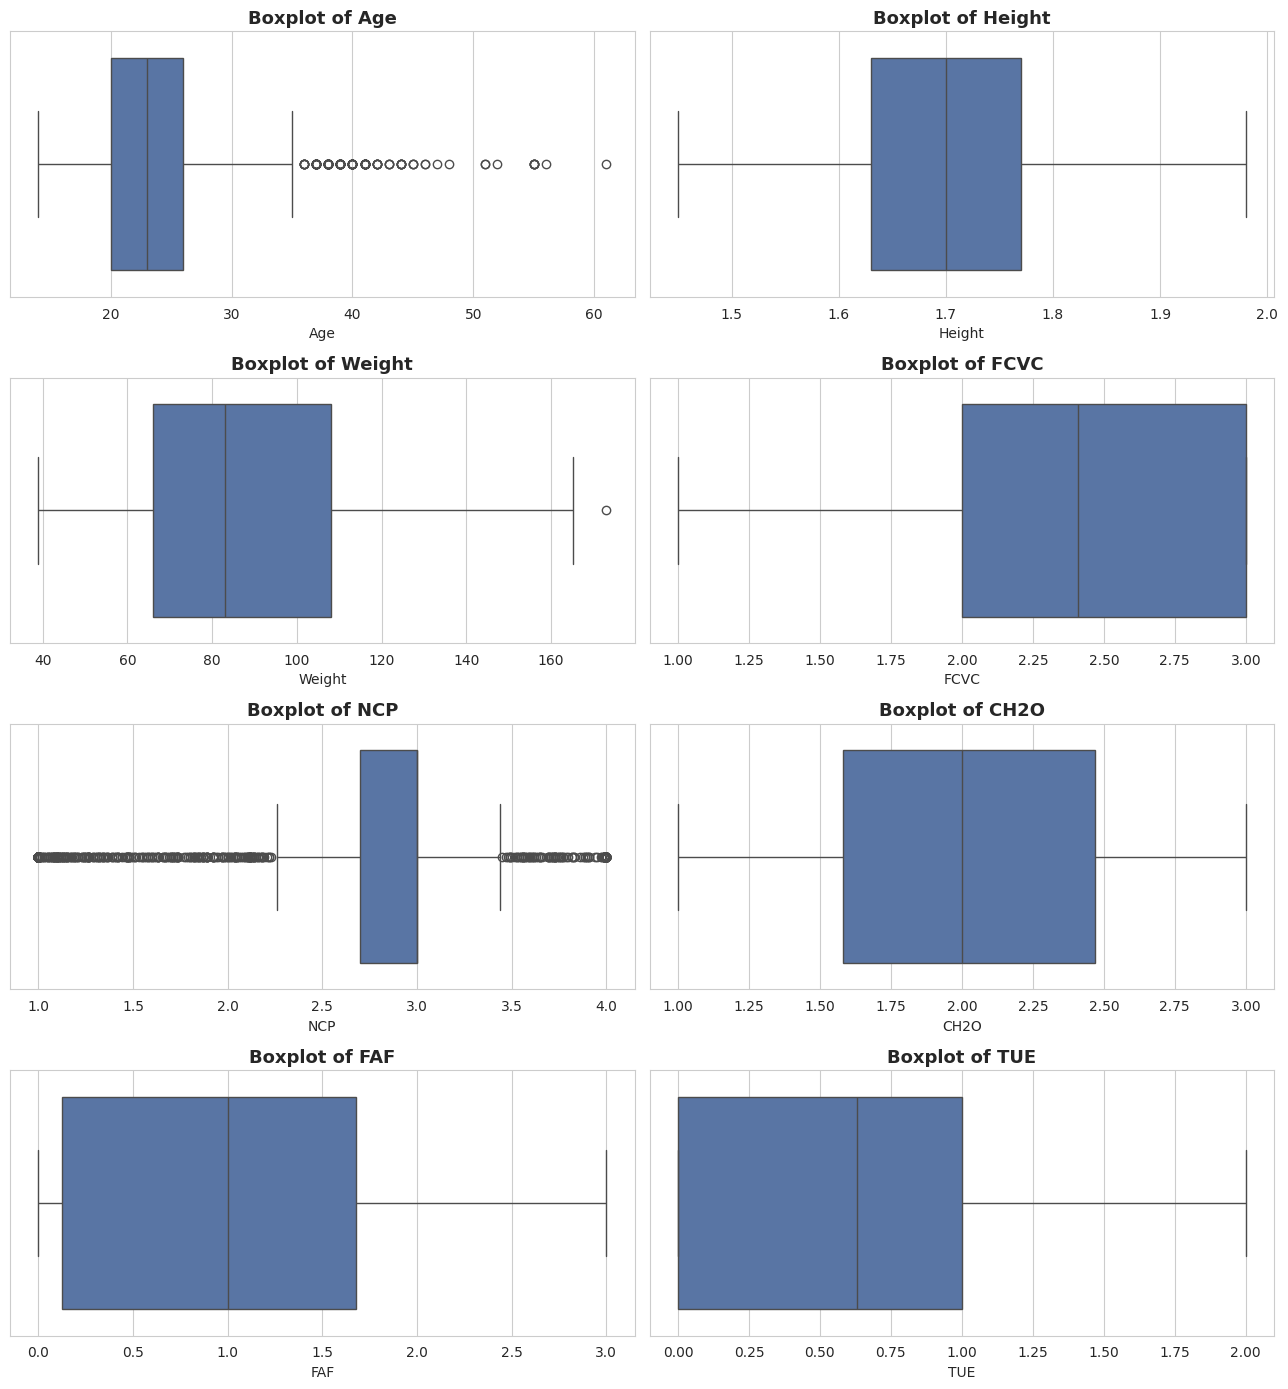

In [37]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(data=df, x=col, ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

**Insight:** `Age` and `Weight` have a few high-end outliers, while `NCP` has several statistical outliers due to its near-discrete nature. However, all values are within **plausible real-world ranges**, suggesting natural variation rather than data-entry errors.


### 8.5 Relationships with Obesity Level

This section looks at how obesity level relates to key numerical and categorical features, to understand which variables actually separate the classes.

**Height vs. Weight, colored by obesity level**

Since obesity is fundamentally driven by the weight-to-height ratio (BMI), this scatter plot should show visible separation between classes.

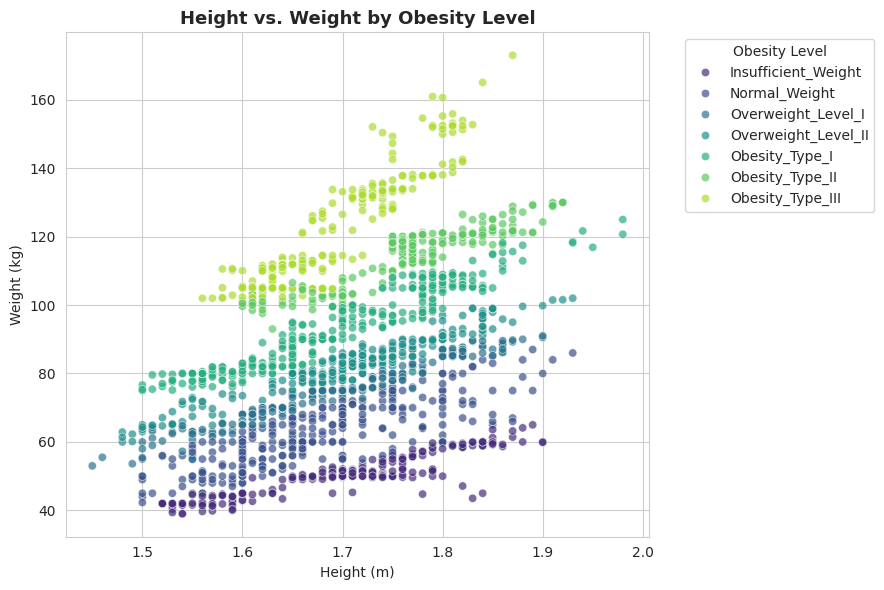

In [38]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue="NObeyesdad",
    hue_order=CLASS_ORDER,
    palette="viridis",
    alpha=0.7
)

plt.title("Height vs. Weight by Obesity Level")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Insight:** obesity classes form clearly separated bands mainly along the **Weight** axis, while Height varies more freely within each class. This confirms weight is the dominant driver of the label, consistent with how BMI-based categories are defined.

**Weight distribution by obesity level**

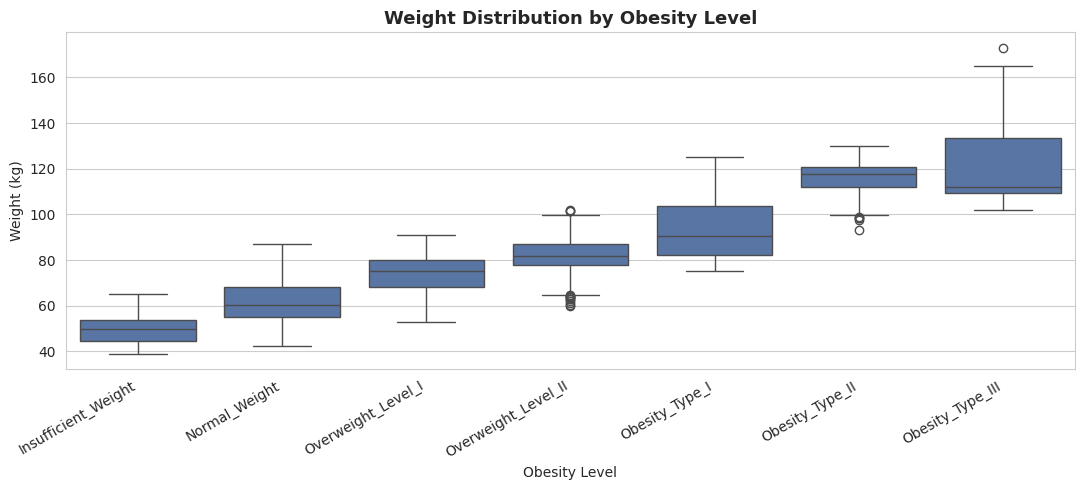

In [39]:
plt.figure(figsize=(11, 5))

sns.boxplot(data=df, x="NObeyesdad", y="Weight", order=CLASS_ORDER, color="#4C72B0")

plt.title("Weight Distribution by Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

**Insight:** median weight increases monotonically across the ordered classes — from ~50 kg (Insufficient Weight) to ~121 kg (Obesity Type III) — confirming the classes are ordinal and weight-driven, as expected.

**Physical activity frequency (FAF) by obesity level**

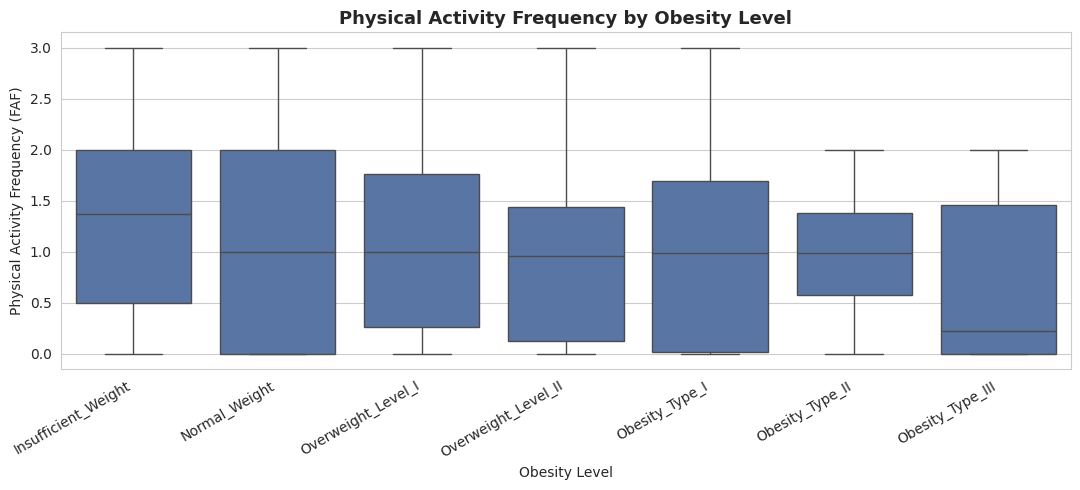

In [40]:
plt.figure(figsize=(11, 5))

sns.boxplot(data=df, x="NObeyesdad", y="FAF", order=CLASS_ORDER, color="#4C72B0")

plt.title("Physical Activity Frequency by Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Physical Activity Frequency (FAF)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

**Insight:** average physical activity is highest for Insufficient/Normal Weight (~1.25) and lowest for Obesity Type III (~0.66). The trend is generally downward with increasing severity but not perfectly monotonic in the middle categories — diet and other lifestyle factors likely interact with activity level rather than activity acting alone.

**Obesity levels by gender**

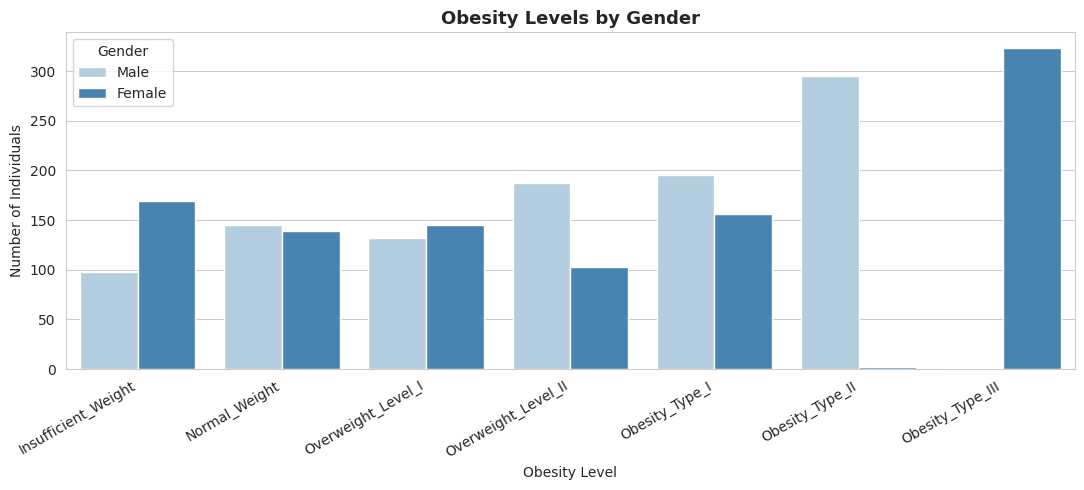

In [41]:
plt.figure(figsize=(11, 5))

sns.countplot(data=df, x="NObeyesdad", hue="Gender", order=CLASS_ORDER, palette="Blues")

plt.title("Obesity Levels by Gender")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

**Insight:** the most striking pattern in the whole dataset appears here — **Obesity Type II is almost entirely male (~99%)** while **Obesity Type III is almost entirely female (~100%)**. Lower/middle classes are close to gender-balanced. This is a strong candidate feature for the modeling stage and worth flagging explicitly on the dashboard.

**Obesity levels by family history of overweight**

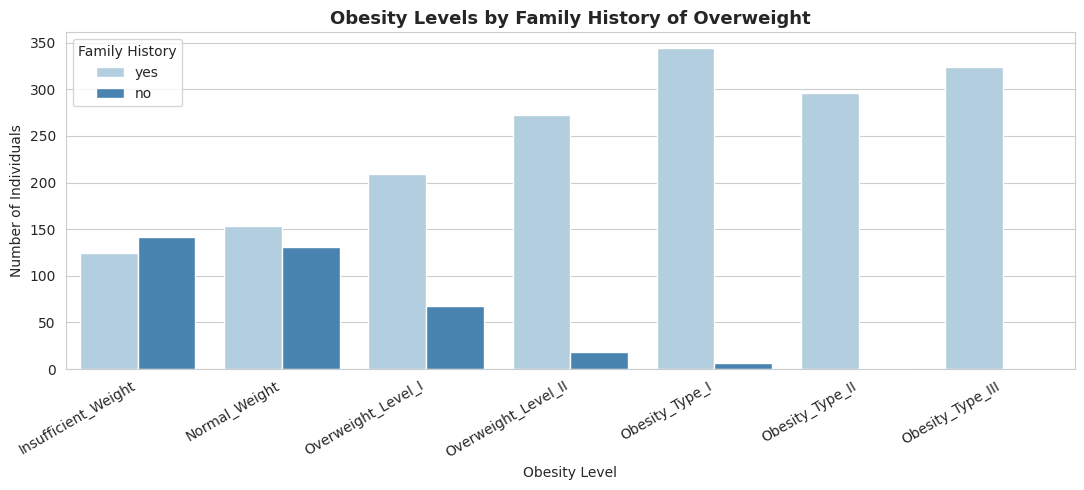

In [42]:
plt.figure(figsize=(11, 5))

sns.countplot(data=df, x="NObeyesdad", hue="family_history_with_overweight", order=CLASS_ORDER, palette="Blues")

plt.title("Obesity Levels by Family History of Overweight")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Family History")

plt.tight_layout()
plt.show()

**Insight:** family history is strongly associated with obesity — about **82% of the full sample** reports a family history of overweight, but that rises to **~99% among individuals classified with any obesity type**. This is one of the clearest single-feature signals in the dataset.

### 8.6 Correlation Between Numerical Variables

A correlation matrix summarizes the linear relationships between numerical features, useful for spotting redundancy (very high correlations) or confirming expected relationships.

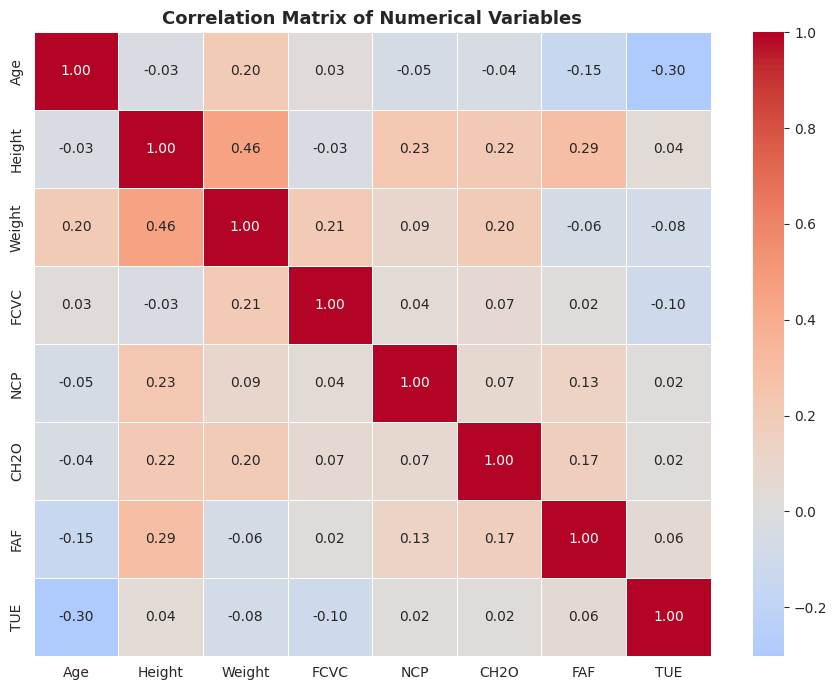

In [43]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

**Insight:** correlations among numerical features are mostly weak-to-moderate — `Height` and `Weight` show the strongest relationship (~0.46), which is expected. No pair is highly collinear (>0.8), so multicollinearity is unlikely to be a concern for the upcoming modeling stage.

## 9. Key Insights & Summary

- **Weight is the dominant driver of obesity classification** — it separates the seven classes cleanly, while height varies more freely within each class.
- **Family history is a strong signal**: ~82% of the overall sample reports a family history of overweight, rising to ~99% among individuals in any obesity category.
- **Gender split by class is highly uneven at the extremes**: Obesity Type II is almost entirely male, while Obesity Type III is almost entirely female — the mid-range classes are roughly gender-balanced.
- **Physical activity (FAF) trends downward with obesity severity** overall (from ~1.27 for Insufficient Weight to ~0.66 for Obesity Type III), though the relationship isn't perfectly monotonic across the middle classes.
- **The target classes are reasonably balanced** (~270–350 individuals per class out of 2,090), so the cleaned dataset is suitable for multi-class classification without heavy resampling.
- **Some categorical features are heavily imbalanced** (`SMOKE`, `SCC` are >95% "no"), meaning they carry limited signal on their own but may still contribute in combination with other variables.
- **No missing values or duplicates remain**, and no numerical feature is highly collinear with another — the dataset is clean and ready for both the Power BI dashboard and the predictive modeling stage.

## 10. Export Cleaned Dataset

The cleaned dataset is exported here for use in the **Power BI dashboard** and in the separate predictive modeling notebook.

In [44]:
from google.colab import files
df.to_csv("obesity_Visualization_dataClean.csv", index=False)
files.download("obesity_Visualization_dataClean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>